BINARY CLASSIFICATION:
ML PROBLEM: USE BREAST CANCER WISCONSIN DATASET AVAILABLE IN SKLEARN
PREDICT IF TUMOUR IS MALIGNANT OR BENIGN

In [ ]:
import numpy as numpy
import pandas as pd
import sklearn as skl
import matplotlib.pyplot as plt

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

In [ ]:
 #load dataset

data = load_breast_cancer()

x = pd.DataFrame(
    data.data,
    columns=data.feature_names #INDEPENDENT VAR W OTHER FEATURES
)

y = pd.Series(
    data.target, # DEPENDENT VAR: 0 means malignant, 1 means benign
    name='tumor_type'
)

print(y.value_counts())

print('feature matrix shape: ', x.shape)
print('target shape: ',y.shape)
print('class names: ',data.target_names)

tumor_type
1    357
0    212
Name: count, dtype: int64
feature matrix shape:  (569, 30)
target shape:  (569,)
class names:  ['malignant' 'benign']


In [ ]:
class_counts = y.value_counts().sort_index() #value.counts() is an available method

class_distribution = pd.DataFrame({
"Class": data.target_names,
"Count" : class_counts,
"Probability": class_counts.values/len(y)
})

print(class_distribution)

                Class  Count  Probability
tumor_type                               
0           malignant    212     0.372583
1              benign    357     0.627417


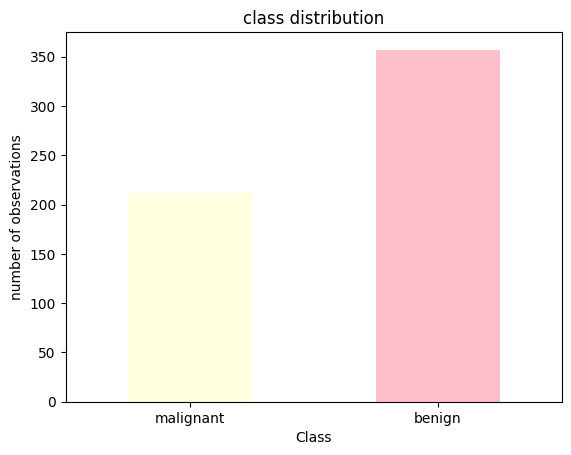

In [ ]:
class_distribution.plot(
    x = 'Class',
    y = 'Count',
    kind='bar', #type of chart
    legend = False,
    color = ['lightyellow', 'pink'] #colours
)

plt.ylabel('number of observations')
plt.title('class distribution')
plt.xticks(rotation=0)
plt.show()

TRAIN TEST SPLIT

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y) #stratify so that test and train have similar distribution of both M and B data

In [ ]:
print('Training size: ', len(y_train))
print('Testing size: ', len(y_test))

print('\n Training proportions: ')
print(y_train.value_counts(normalize=True).sort_index()) #check how many and % of M and B in both train and test

print('\n Testing proportions: ')
print(y_test.value_counts(normalize=True).sort_index())

Training size:  455
Testing size:  114

 Training proportions: 
tumor_type
0    0.373626
1    0.626374
Name: proportion, dtype: float64

 Testing proportions: 
tumor_type
0    0.368421
1    0.631579
Name: proportion, dtype: float64


LOGISTIC REGRESSION

In [ ]:
model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000)
)

model.fit(x_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression', LogisticRegression(max_iter=1000))])

In [ ]:
probabilities = model.predict_proba(x_test) # predict prob in test and print first 5

print(probabilities[:5])

[[9.99999941e-01 5.88824186e-08]
 [1.13351672e-05 9.99988665e-01]
 [9.93589175e-01 6.41082462e-03]
 [4.66491463e-01 5.33508537e-01]
 [9.99999999e-01 6.52500097e-10]]


In [ ]:
results = pd.DataFrame({
    "Actual_class": y_test.values,
    "P_malignant": probabilities[:,0], # Probability of Malignant (class 0)
    "P_benign" : probabilities[:,1]  # Probability of Benign (class 1)
})

In [ ]:
results ["Actual label"] = results["Actual_class"].map({
    0: 'Malignant',
    1: 'Benign'
})

print(
    results[
        ["Actual label", "P_malignant", "P_benign"]
    ].head(10)
)

  Actual label  P_malignant      P_benign
0    Malignant     1.000000  5.888242e-08
1       Benign     0.000011  9.999887e-01
2    Malignant     0.993589  6.410825e-03
3       Benign     0.466491  5.335085e-01
4    Malignant     1.000000  6.525001e-10
5       Benign     0.007840  9.921604e-01
6       Benign     0.000017  9.999828e-01
7    Malignant     0.999999  5.635275e-07
8    Malignant     0.999946  5.431637e-05
9    Malignant     1.000000  8.041849e-11


In [ ]:
threshold = 0.5

# Ensure 'Actual label' column exists first
results ["Actual label"] = results["Actual_class"].map({
    0: 'Malignant',
    1: 'Benign'
})

results["Predicted malignant"] = (
    results["P_malignant"] >= threshold
).astype(int)

# Now, the 'Predicted malignant' column uses 1 for predicted malignant, 0 for benign.
# To align with Actual_class (0=malignant, 1=benign), we invert this.
results["Predicted malignant"] = 1 - results["Predicted malignant"]

results["Predicted_label"] = results[
    "Predicted malignant"
].map({
    0: "malignant", # If Predicted malignant is 0, then it's 'malignant'
    1: "benign"     # If Predicted malignant is 1, then it's 'benign'
})

print(
    results[
        [
        "Actual label",
        "P_malignant",
        "Predicted_label"
        ]
    ].head(10)
)

  Actual label  P_malignant Predicted_label
0    Malignant     1.000000       malignant
1       Benign     0.000011          benign
2    Malignant     0.993589       malignant
3       Benign     0.466491          benign
4    Malignant     1.000000       malignant
5       Benign     0.007840          benign
6       Benign     0.000017          benign
7    Malignant     0.999999       malignant
8    Malignant     0.999946       malignant
9    Malignant     1.000000       malignant


In [ ]:
for threshold in [0.30, 0.50, 0.70]:
    # Raw predictions: 1 for predicted malignant (if P_malignant >= threshold), 0 for benign.
    predictions_raw = (
        results["P_malignant"] >= threshold
    ).astype(int)
    # Align predictions: 0 for predicted malignant, 1 for predicted benign
    predictions_aligned = 1 - predictions_raw

    print(
        f"Threshold = {threshold}: "
        f"Predicted malignant cases = { (predictions_aligned == 0).sum() }"
    )

Threshold = 0.3: Predicted malignant cases = 46
Threshold = 0.5: Predicted malignant cases = 42
Threshold = 0.7: Predicted malignant cases = 40


In [ ]:
# actual_malignant now has 0 for Malignant, 1 for Benign
actual_malignant = y_test.values # 0 for Malignant, 1 for Benign

for threshold in [0.30, 0.50, 0.70]:
    # Predict Malignant (class 0) if probability of Malignant (probabilities[:, 0]) is >= threshold.
    # y_pred should be 0 for predicted Malignant, 1 for predicted Benign.
    # If P(Malignant) >= threshold, then (probabilities[:, 0] < threshold) is False, .astype(int) is 0 (Malignant).
    # If P(Malignant) < threshold, then (probabilities[:, 0] < threshold) is True, .astype(int) is 1 (Benign).
    y_pred = (probabilities[:, 0] < threshold).astype(int)

    cm = confusion_matrix(
        actual_malignant,
        y_pred
    )
    accuracy = accuracy_score(actual_malignant, y_pred)

    print(f"\nConfusion Matrix for Threshold = {threshold}:")
    print(cm)
    print(f"Accuracy Score: {accuracy:.4f}")


Confusion Matrix for Threshold = 0.3:
[[41  1]
 [ 5 67]]
Accuracy Score: 0.9474

Confusion Matrix for Threshold = 0.5:
[[41  1]
 [ 1 71]]
Accuracy Score: 0.9825

Confusion Matrix for Threshold = 0.7:
[[40  2]
 [ 0 72]]
Accuracy Score: 0.9825


# accuracy = tp+tn/all
(how many corrrectly detected M or B)
# precision = tp/tp+fp
(among detected malignant how many were ACTUALLY malignant)
# recall = tp/tp+fn [sensitivity]
(among malignant, how many were detected malignant)
# specificity = tn/tn+fp
(among benign, how many detected benign)
# Fl score = 2(precision*recall/precision+recall)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [ ]:
# For consistency, let's use a threshold of 0.5 for the individual metrics here
threshold_for_predictions_cell = 0.5
predictions_for_metrics_raw = (results["P_malignant"] >= threshold_for_predictions_cell).astype(int)
predictions_for_metrics = 1 - predictions_for_metrics_raw # 0=malignant, 1=benign

print(
    "Sklearn accuracy: ",
    accuracy_score(y_test, predictions_for_metrics)
)

print(
    "Sklearn precision: ",
    precision_score(y_test, predictions_for_metrics, pos_label=0) # Malignant is now 0
)

print(
    "Sklearn recall: ",
    recall_score(y_test, predictions_for_metrics, pos_label=0) # Malignant is now 0
)

Sklearn accuracy:  0.9824561403508771
Sklearn precision:  0.9761904761904762
Sklearn recall:  0.9761904761904762


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# actual_malignant now has 0 for Malignant, 1 for Benign
actual_malignant = y_test.values # 0 for Malignant, 1 for Benign

for threshold in [0.30, 0.50, 0.70]:
    # Predict Malignant (class 0) if probability of Malignant (probabilities[:, 0]) is >= threshold.
    # y_pred should be 0 for predicted Malignant, 1 for predicted Benign.
    y_pred = (probabilities[:, 0] < threshold).astype(int) # if P(M) >= T, then F -> 0 (Malignant). if P(M) < T, then T -> 1 (Benign)

    cm = confusion_matrix(
        actual_malignant,
        y_pred
    )
    accuracy = accuracy_score(actual_malignant, y_pred)
    # Ensure pos_label is 0 for malignant
    precision = precision_score(actual_malignant, y_pred, pos_label=0, zero_division=0)
    recall = recall_score(actual_malignant, y_pred, pos_label=0, zero_division=0)
    f1 = f1_score(actual_malignant, y_pred, pos_label=0, zero_division=0)

    print(f"\n--- Metrics for Threshold = {threshold} ---")
    print(f"Confusion Matrix:\n{cm}")
    print(f"Accuracy Score: {accuracy:.4f}")
    print(f"Precision Score: {precision:.4f}")
    print(f"Recall Score: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")


--- Metrics for Threshold = 0.3 ---
Confusion Matrix:
[[41  1]
 [ 5 67]]
Accuracy Score: 0.9474
Precision Score: 0.8913
Recall Score: 0.9762
F1 Score: 0.9318

--- Metrics for Threshold = 0.5 ---
Confusion Matrix:
[[41  1]
 [ 1 71]]
Accuracy Score: 0.9825
Precision Score: 0.9762
Recall Score: 0.9762
F1 Score: 0.9762

--- Metrics for Threshold = 0.7 ---
Confusion Matrix:
[[40  2]
 [ 0 72]]
Accuracy Score: 0.9825
Precision Score: 1.0000
Recall Score: 0.9524
F1 Score: 0.9756


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd

metrics_data = []
thresholds = [0.1, 0.3, 0.5, 0.7, 0.9]

# actual_malignant now has 0 for Malignant, 1 for Benign
actual_malignant = y_test.values # 0 for Malignant, 1 for Benign

for threshold in thresholds:
    # Predict Malignant (class 0) if probability of Malignant (probabilities[:, 0]) is >= threshold.
    # y_pred should be 0 for predicted Malignant, 1 for predicted Benign.
    y_pred = (probabilities[:, 0] < threshold).astype(int) # if P(M) >= T, then F -> 0 (Malignant). if P(M) < T, then T -> 1 (Benign)

    cm = confusion_matrix(
        actual_malignant,
        y_pred
    )
    tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0,0,0,0) # tn=cm[0,0], fp=cm[0,1], fn=cm[1,0], tp=cm[1,1]

    accuracy = accuracy_score(actual_malignant, y_pred)
    # Ensure pos_label is 0 for malignant
    precision = precision_score(actual_malignant, y_pred, pos_label=0, zero_division=0)
    recall = recall_score(actual_malignant, y_pred, pos_label=0, zero_division=0)
    f1 = f1_score(actual_malignant, y_pred, pos_label=0, zero_division=0)

    metrics_data.append({
        'Threshold': threshold,
        'TN': tn,
        'FP': fp,
        'FN': fn,
        'TP': tp,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })

metrics_df = pd.DataFrame(metrics_data)
display(metrics_df.round(3))

,Threshold,TN,FP,FN,TP,Accuracy,Precision,Recall,F1-Score
0,0.1,41,1,11,61,0.895,0.788,0.976,0.872
1,0.3,41,1,5,67,0.947,0.891,0.976,0.932
2,0.5,41,1,1,71,0.982,0.976,0.976,0.976
3,0.7,40,2,0,72,0.982,1.000,0.952,0.976
4,0.9,37,5,0,72,0.956,1.000,0.881,0.937
